# Step 6: Model Evaluation & Hyperparameter Tuning

This notebook provides an interactive view of:
1. PR & ROC Curves for all baseline models
2. Optimal threshold selection for XGBoost
3. Hyperparameter tuning results
4. Final test evaluation of tuned models

In [1]:
import pandas as pd
import numpy as np
import joblib
import os
import sys
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, average_precision_score,
    roc_auc_score, precision_recall_curve, roc_curve, f1_score
)

sys.path.append(os.path.abspath('..'))

In [2]:
# Load processed data and recreate the same test split
df = pd.read_csv('../data/processed/processed_transactions.csv')
y = df['isFraud']
X = df.drop(columns=['isFraud'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(f'Test set: {X_test.shape[0]:,} rows | Fraud cases: {y_test.sum():,}')

Test set: 1,272,524 rows | Fraud cases: 1,643


## 1. PR Curves — All Baseline Models

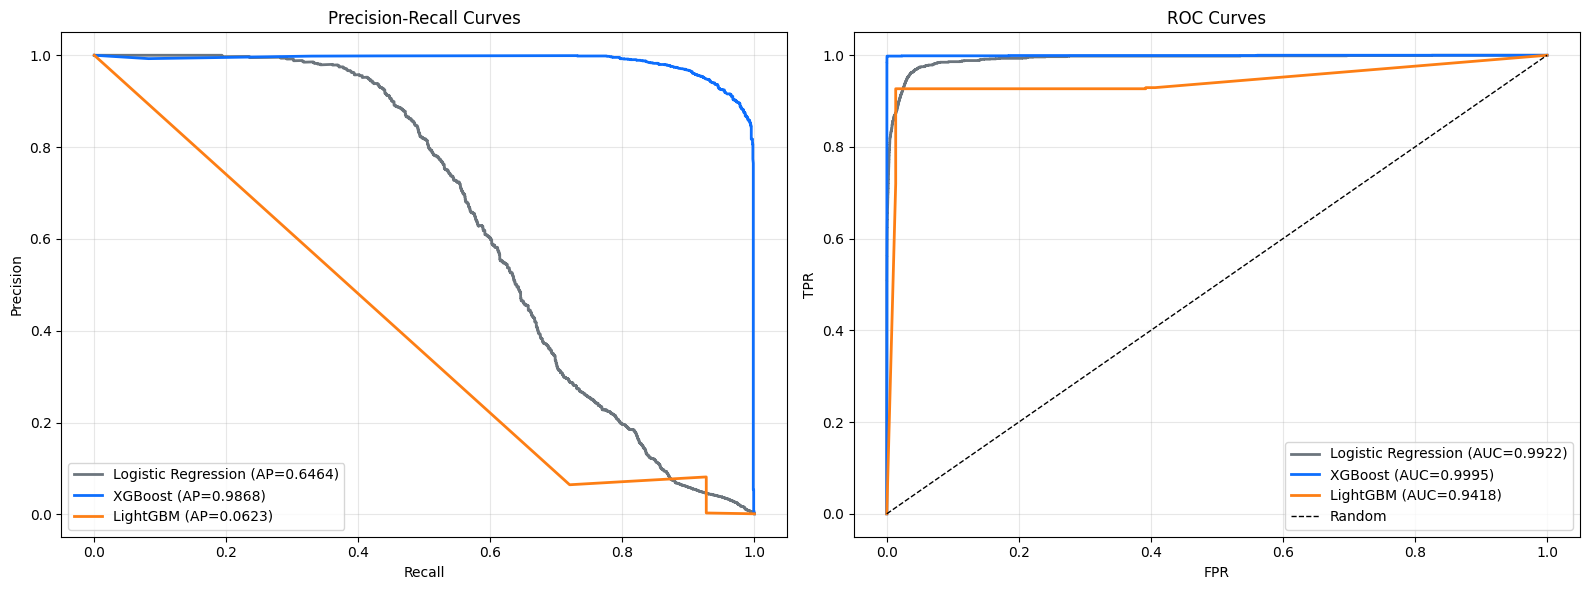

In [3]:
models = {
    'Logistic Regression': joblib.load('../models/baseline_logreg.pkl'),
    'XGBoost':             joblib.load('../models/xgboost_model.pkl'),
    'LightGBM':            joblib.load('../models/lightgbm_model.pkl'),
}

colors = ['#6c757d', '#0d6efd', '#fd7e14']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for (name, model), color in zip(models.items(), colors):
    y_prob = model.predict_proba(X_test)[:, 1]
    # PR Curve
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    axes[0].plot(recall, precision, label=f'{name} (AP={ap:.4f})', color=color, lw=2)
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})', color=color, lw=2)

axes[0].set_title('Precision-Recall Curves'); axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot([0,1],[0,1],'k--',lw=1,label='Random')
axes[1].set_title('ROC Curves'); axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/pr_roc_curves.png', dpi=150)
plt.show()

## 2. Optimal Threshold for XGBoost

In [4]:
xgb_model = models['XGBoost']
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_xgb)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores[:-1])
best_thresh = thresholds[best_idx]

print(f'Optimal Threshold: {best_thresh:.4f} | Best F1: {f1_scores[best_idx]:.4f}')

print('\n--- Default Threshold (0.5) ---')
print(classification_report(y_test, (y_prob_xgb >= 0.5).astype(int)))

print(f'\n--- Optimal Threshold ({best_thresh:.4f}) ---')
print(classification_report(y_test, (y_prob_xgb >= best_thresh).astype(int)))

Optimal Threshold: 0.9983 | Best F1: 0.9400

--- Default Threshold (0.5) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.85      0.99      0.92      1643

    accuracy                           1.00   1272524
   macro avg       0.93      1.00      0.96   1272524
weighted avg       1.00      1.00      1.00   1272524


--- Optimal Threshold (0.9983) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.94      0.94      0.94      1643

    accuracy                           1.00   1272524
   macro avg       0.97      0.97      0.97   1272524
weighted avg       1.00      1.00      1.00   1272524



## 3. Tuned Model Results
> Run `src/models/tune_model.py` first to generate the tuned model files.

In [5]:
tuned = {
    'XGBoost (Tuned)':  joblib.load('../models/xgboost_tuned.pkl'),
    'LightGBM (Tuned)': joblib.load('../models/lightgbm_tuned.pkl'),
}

print('=== FINAL TEST EVALUATION ===')
for name, model in tuned.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    print(f'\n--- {name} ---')
    print(classification_report(y_test, y_pred))
    print(f'PR AUC: {average_precision_score(y_test, y_prob):.4f}')

=== FINAL TEST EVALUATION ===

--- XGBoost (Tuned) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.87      0.99      0.93      1643

    accuracy                           1.00   1272524
   macro avg       0.93      1.00      0.96   1272524
weighted avg       1.00      1.00      1.00   1272524

PR AUC: 0.9882

--- LightGBM (Tuned) ---
              precision    recall  f1-score   support

           0       1.00      0.96      0.98   1270881
           1       0.03      0.93      0.06      1643

    accuracy                           0.96   1272524
   macro avg       0.52      0.94      0.52   1272524
weighted avg       1.00      0.96      0.98   1272524

PR AUC: 0.0292


In [6]:
# Print tuning results summary
with open('../reports/tuning_results.txt', 'r') as f:
    print(f.read())

=== Step 6: Hyperparameter Tuning Results ===

Search sample size: 200,000 rows
CV folds: 3 | Iterations per model: 10

Best XGBoost Params:
{'subsample': 1.0, 'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 1.0}

Best LightGBM Params:
{'reg_alpha': 0.0, 'num_leaves': 127, 'n_estimators': 300, 'min_child_samples': 20, 'learning_rate': 0.05}


=== Final Test Results (Held-out 20%) ===

--- XGBoost (Tuned) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.87      0.99      0.93      1643

    accuracy                           1.00   1272524
   macro avg       0.93      1.00      0.96   1272524
weighted avg       1.00      1.00      1.00   1272524

PR AUC: 0.9882

--- LightGBM (Tuned) ---
              precision    recall  f1-score   support

           0       1.00      0.96      0.98   1270881
           1       0.03      0.93      0.06      1643

    accuracy             